Loaded file: 2020-001-72865_5755-2659-315.npz
Chip shape (Timesteps, Height, Width, Bands): (5, 128, 128, 16)


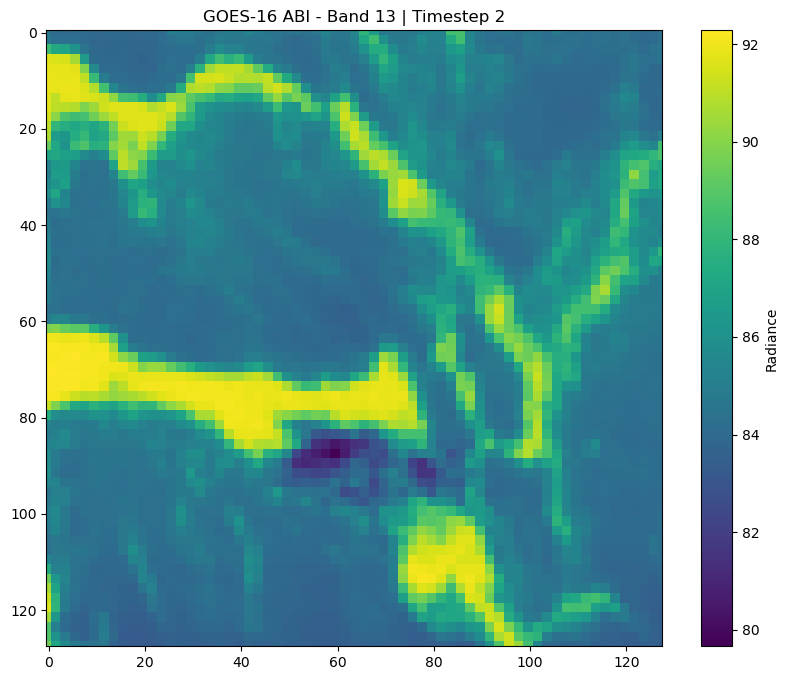

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

# 1. Point to your output directory
# data_dir = '/home/al8425b-hpc/NASA/cropTest/testData/cropTestOutput/'
data_dir = '/home/al8425b-hpc/NASA/cropTest/testData/cropTestOuput'
# data_dir = './testData/cropTestOutput/'


# 2. Get all .npz files and pick one right from the middle of the batch
all_files = sorted([f for f in os.listdir(data_dir) if f.endswith('.npz')])
middle_index = len(all_files) // 2
selected_file = all_files[middle_index]
file_path = os.path.join(data_dir, selected_file)

print(f"Loaded file: {selected_file}")

# 3. Load the data archive
archive = np.load(file_path, allow_pickle=True)
chip = archive['chip']
print(f"Chip shape (Timesteps, Height, Width, Bands): {chip.shape}")

# 4. Set your parameters
# Timestep: 0 to 4 (Index 2 is the exact moment of the radar overpass)
# Band: 0 to 15 (Index 12 is Band 13: Thermal Infrared, great for clouds)
timestep = 2
band_index = 12

# Extract the 2D image slice
image_slice = chip[timestep, :, :, band_index]

# 5. Plot the image directly in the notebook
plt.figure(figsize=(10, 8))
plt.imshow(image_slice, cmap='viridis') # 'viridis' is great for infrared contrast
plt.colorbar(label='Radiance')
plt.title(f'GOES-16 ABI - Band {band_index + 1} | Timestep {timestep}')
plt.show()